In [22]:
# Pitch‐based comparative analysis using process_pitch
import os
import glob
import pandas as pd
import numpy as np
from librosa.sequence import dtw

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))

# Config
LOCAL_BASE = "./data-analysis/downloaded_audios"
PITCH_MOD_REFS = {
    "control": "./data-analysis/reference_audios/musavoice_testing/pitch_mod_control.wav",
    "tool": "./data-analysis/reference_audios/musavoice_testing/pitch_mod_tool.wav",
}
VOCAL_TONE_REFS = {
    "control": "./data-analysis/reference_audios/musavoice_testing/vocal_tone_control.wav",
    "tool": "./data-analysis/reference_audios/musavoice_testing/vocal_tone_tool.wav",
}

GPUs: []


In [23]:
import os
import sys
import json
import numpy as np
from pathlib import Path

# Ensure imports + relative model paths work
PY_SERVICE_ROOT = Path("/Users/isabelleoktay/skynote/audio-analyzer/python-service").resolve()
if str(PY_SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(PY_SERVICE_ROOT))
os.chdir(PY_SERVICE_ROOT)

from feature_extraction.pitch_mod import extract_pitch_mod
from feature_extraction.vocal_tone import extract_vocal_tone
from utils.smoothing import smooth_data

REF_DIR = (PY_SERVICE_ROOT / "data-analysis" / "reference_audios" / "musavoice_testing").resolve()
AUDIO_EXTS = {".wav", ".mp3", ".m4a", ".flac", ".ogg", ".aiff"}

def infer_gender_from_name(name: str) -> str:
    n = name.lower()
    if any(x in n for x in ["male", "tenor", "bass"]):
        return "male"
    return "female"

def format_output(class_names, preds):
    if preds is None or len(class_names) == 0:
        return []
    arr = np.asarray(preds)
    if arr.ndim != 2 or arr.shape[0] == 0:
        return []

    smoothed = np.zeros_like(arr, dtype=float)
    for c in range(arr.shape[1]):
        smoothed[:, c] = smooth_data(arr[:, c], window_size=3, filter_type="median")

    return [
        {"label": class_names[i], "data": smoothed[:, i].tolist()}
        for i in range(len(class_names))
    ]

def extract_both(audio_path: Path, use_clap=True, use_whisper=True, monitor_resources=False):
    gender = infer_gender_from_name(audio_path.name)

    pm_wh_names, pm_wh_pred, pm_cl_names, pm_cl_pred = extract_pitch_mod(
        str(audio_path),
        gender,
        use_clap=use_clap,
        use_whisper=use_whisper,
        monitor_resources=monitor_resources,
    )

    vt_wh_names, vt_wh_pred, vt_cl_names, vt_cl_pred = extract_vocal_tone(
        str(audio_path),
        gender,
        use_clap=use_clap,
        use_whisper=use_whisper,
        monitor_resources=monitor_resources,
    )

    return {
        "audio_name": audio_path.name,
        "audio_path": str(audio_path),
        "gender_used": gender,
        "pitch_mod": {
            "CLAP": format_output(pm_cl_names, pm_cl_pred) if use_clap else [],
            "Whisper": format_output(pm_wh_names, pm_wh_pred) if use_whisper else [],
        },
        "vocal_tone": {
            "CLAP": format_output(vt_cl_names, vt_cl_pred) if use_clap else [],
            "Whisper": format_output(vt_wh_names, vt_wh_pred) if use_whisper else [],
        },
    }

audio_files = [p for p in REF_DIR.rglob("*") if p.suffix.lower() in AUDIO_EXTS]
results = []

for p in audio_files:
    fname = p.name.lower()
    gender = infer_gender_from_name(fname)
    result = {
        "audio_name": p.name,
        "audio_path": str(p),
        "gender_used": gender,
        "pitch_mod": {},
        "vocal_tone": {},
    }
    try:
        if "pitch_mod" in fname:
            pm_wh_names, pm_wh_pred, pm_cl_names, pm_cl_pred = extract_pitch_mod(
                str(p), gender, use_clap=True, use_whisper=True, monitor_resources=False
            )
            result["pitch_mod"] = {
                "CLAP": format_output(pm_cl_names, pm_cl_pred),
                "Whisper": format_output(pm_wh_names, pm_wh_pred),
            }
        if "vocal_tone" in fname:
            vt_wh_names, vt_wh_pred, vt_cl_names, vt_cl_pred = extract_vocal_tone(
                str(p), gender, use_clap=True, use_whisper=True, monitor_resources=False
            )
            result["vocal_tone"] = {
                "CLAP": format_output(vt_cl_names, vt_cl_pred),
                "Whisper": format_output(vt_wh_names, vt_wh_pred),
            }
        print(f"✓ {p.name}")
    except Exception as e:
        print(f"✗ {p.name}: {e}")
        result["error"] = str(e)
    results.append(result)

print(f"Processed {len(results)} files.")

out_path = REF_DIR / "reference_audio_features.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print("Saved:", out_path)

KeyboardInterrupt: 

In [8]:
import os
import json
import numpy as np
import librosa
from pathlib import Path
from feature_extraction.pitch_mod import extract_pitch_mod
from feature_extraction.vocal_tone import extract_vocal_tone
from utils.smoothing import smooth_data

AUDIO_EXTS = {".wav", ".mp3", ".m4a", ".flac", ".ogg", ".aiff"}
DATA_ROOT = Path("./data-analysis/downloaded_audios/musavoice_testing")
REF_FEATURES_PATH = Path("./data-analysis/reference_audios/musavoice_testing/reference_audio_features.json")

# Load reference features
with open(REF_FEATURES_PATH, "r") as f:
    ref_features = json.load(f)

def get_ref_feature(feature_type, ref_type, extractor="CLAP", label=None):
    # feature_type: "pitch_mod" or "vocal_tone"
    # ref_type: "tool" or "control"
    # extractor: "CLAP" or "Whisper"
    # label: e.g. "straight", "belt", etc. (optional, for multi-label features)
    fname = f"{feature_type}_{ref_type}.wav"
    for ref in ref_features:
        if ref["audio_name"] == fname:
            feats = ref[feature_type][extractor]
            if label is not None:
                for f in feats:
                    if f["label"] == label:
                        return np.array(f["data"])
            else:
                # Return all labels as a dict
                return {f["label"]: np.array(f["data"]) for f in feats}
    return None

def extract_feature(audio_path, feature_type, gender):
    if feature_type == "pitch_mod":
        names, preds, _, _ = extract_pitch_mod(str(audio_path), gender, use_clap=True, use_whisper=True)
    else:
        names, preds, _, _ = extract_vocal_tone(str(audio_path), gender, use_clap=True, use_whisper=True)
    arr = np.asarray(preds)
    if arr.ndim == 2 and arr.shape[0] > 0:
        arr = smooth_data(arr, window_size=3, filter_type="median")
    return arr, names

def dtw_distance(a, b):
    D, wp = librosa.sequence.dtw(a.T, b.T, metric='euclidean')
    return D[-1, -1] / len(wp)

results = []
for subject_dir in DATA_ROOT.iterdir():
    if not subject_dir.is_dir():
        continue
    for section_dir in subject_dir.iterdir():
        if not section_dir.is_dir():
            continue
        feature_type = "pitch_mod" if section_dir.name.startswith("pitch-modulation-") else "vocal_tone"
        ref_type = "tool" if "tool" in section_dir.name else "control"
        # Example: compare only the "CLAP" extractor and the first label
        ref_feats = get_ref_feature(feature_type, ref_type, extractor="CLAP")
        if ref_feats is None:
            continue

        before = section_dir / "before.wav"
        after = section_dir / "after.wav"
        for timing, audio_path in [("before", before), ("after", after)]:
            if audio_path.exists():
                user_feat, user_labels = extract_feature(audio_path, feature_type, gender="female")
                # Compare each label in user_feat to the corresponding label in ref_feats
                for i, label in enumerate(user_labels):
                    if label in ref_feats:
                        ref_data = ref_feats[label]
                        user_data = user_feat[:, i]
                        dist = dtw_distance(user_data.reshape(-1, 1), ref_data.reshape(-1, 1))
                        results.append({
                            "subject": subject_dir.name,
                            "section": section_dir.name,
                            "timing": timing,
                            "label": label,
                            "distance_to_ref": dist,
                        })

import pandas as pd
df = pd.DataFrame(results)
df["improvement"] = df.groupby(["subject", "section", "label"])["distance_to_ref"].transform(lambda x: x.iloc[0] - x.iloc[-1])
print(df)

CLAP vocal tone inference metrics: {'feature_type': 'clap_vocal_tone', 'time_seconds': 9.563079357147217, 'cpu_before_start_percent': 0.0039627384296909655, 'cpu_overall_avg': 23.594382022471912, 'cpu_peak': 100.0, 'cpu_overall_avg_above_baseline': 23.59041928404222, 'ram_before_start_percent': 82.50080585538961, 'ram_avg': 82.91573033707863, 'ram_peak': 84.4, 'ram_avg_above_baseline': 0.4149244816890132, 'cpu_per_core_last': [81.8, 72.7, 66.7, 63.6, 54.5, 58.3, 83.3, 80.0, 90.9, 91.7], 'cpu_per_core_avg': [87.26629213483146, 84.68089887640448, 81.41685393258426, 79.85393258426964, 78.5191011235955, 76.84719101123595, 84.80898876404495, 85.01910112359552, 85.04044943820224, 84.96966292134832], 'cpu_per_core_avg_above_baseline': [87.18870082919787, 84.61875190021048, 81.38486369156696, 79.81514802120591, 78.49547994956032, 76.83118480097423, 84.71140633021382, 84.96597381323029, 84.97991417278749, 84.88694814979723]}
Whisper vocal tone inference metrics: {'feature_type': 'whisper_vocal_

In [11]:
from pathlib import Path

OUT_DIR = Path("./data-analysis/results/musavoice_testing")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# CSV
csv_path = OUT_DIR / "before_after_dtw_results.csv"
df.to_csv(csv_path, index=False)

# Optional: Excel
xlsx_path = OUT_DIR / "before_after_dtw_results.xlsx"
df.to_excel(xlsx_path, index=False)

print("Saved CSV:", csv_path.resolve())
print("Saved XLSX:", xlsx_path.resolve())

Saved CSV: /Users/isabelleoktay/skynote/audio-analyzer/python-service/data-analysis/results/musavoice_testing/before_after_dtw_results.csv
Saved XLSX: /Users/isabelleoktay/skynote/audio-analyzer/python-service/data-analysis/results/musavoice_testing/before_after_dtw_results.xlsx


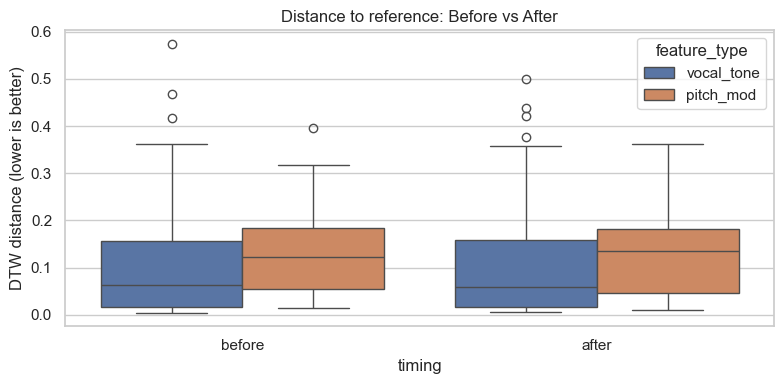

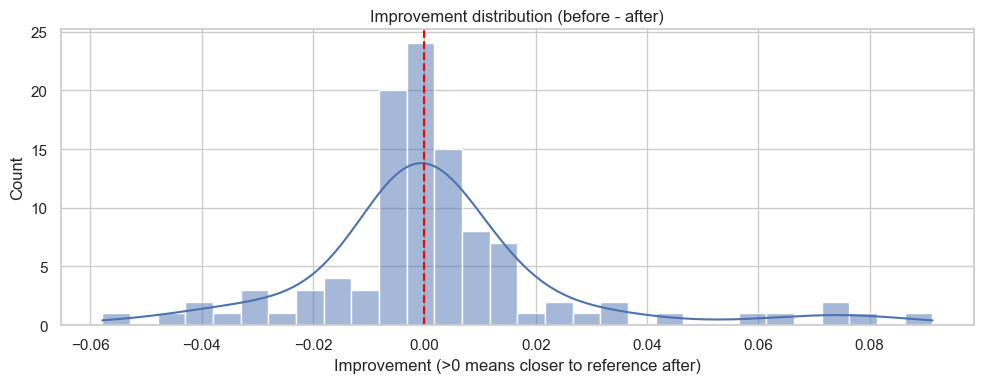

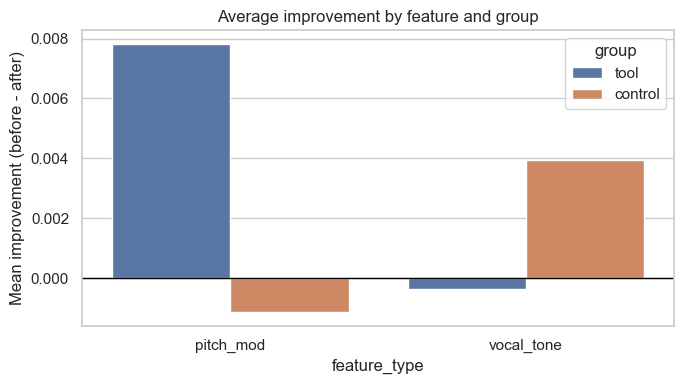

,feature_type,group,improvement
1,pitch_mod,tool,0.007823
2,vocal_tone,control,0.003930
3,vocal_tone,tool,-0.000368
0,pitch_mod,control,-0.001145


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# --- prep ---
viz = df.copy()
viz["feature_type"] = np.where(viz["section"].str.startswith("pitch-modulation-"), "pitch_mod", "vocal_tone")
viz["group"] = np.where(viz["section"].str.contains("tool"), "tool", "control")

# 1) Before vs After distribution (lower distance is better)
plt.figure(figsize=(8, 4))
sns.boxplot(data=viz, x="timing", y="distance_to_ref", hue="feature_type")
plt.title("Distance to reference: Before vs After")
plt.ylabel("DTW distance (lower is better)")
plt.tight_layout()
plt.show()

# 2) Paired change per subject/section/label
paired = (
    viz.pivot_table(
        index=["subject", "section", "label", "feature_type", "group"],
        columns="timing",
        values="distance_to_ref",
        aggfunc="mean"
    )
    .reset_index()
    .dropna(subset=["before", "after"])
)
paired["improvement"] = paired["before"] - paired["after"]  # positive = improved

plt.figure(figsize=(10, 4))
sns.histplot(paired["improvement"], bins=30, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Improvement distribution (before - after)")
plt.xlabel("Improvement (>0 means closer to reference after)")
plt.tight_layout()
plt.show()

# 3) Mean improvement by group and feature type
agg = (
    paired.groupby(["feature_type", "group"], as_index=False)["improvement"]
    .mean()
    .sort_values("improvement", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=agg, x="feature_type", y="improvement", hue="group")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average improvement by feature and group")
plt.ylabel("Mean improvement (before - after)")
plt.tight_layout()
plt.show()

display(agg)

,feature_type,test,n_subjects,mean_tool,mean_control,mean_diff_tool_minus_control,p_value
0,pitch_mod,wilcoxon_paired_tool_vs_control,4,0.006560,-0.001145,0.007704,0.625000
1,vocal_tone,wilcoxon_paired_tool_vs_control,7,-0.000368,0.003930,-0.004298,0.578125


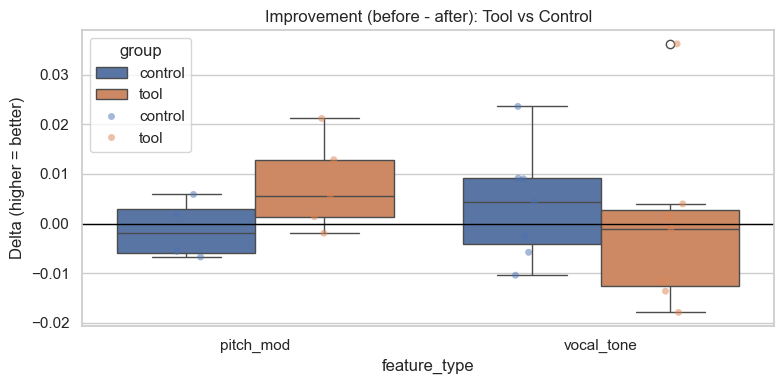

In [15]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Build paired before/after rows
paired = (
    df.pivot_table(
        index=["subject", "section", "label"],
        columns="timing",
        values="distance_to_ref",
        aggfunc="mean"
    )
    .reset_index()
    .dropna(subset=["before", "after"])
)

paired["feature_type"] = np.where(
    paired["section"].str.startswith("pitch-modulation-"), "pitch_mod", "vocal_tone"
)
paired["group"] = np.where(paired["section"].str.contains("tool"), "tool", "control")
paired["delta"] = paired["before"] - paired["after"]  # higher = more improvement

# 2) Subject-level aggregation to avoid overweighting labels
subj = (
    paired.groupby(["subject", "feature_type", "group"], as_index=False)["delta"]
    .mean()
)

# 3) Compare tool vs control within each feature_type
rows = []
for ft, g in subj.groupby("feature_type"):
    pvt = g.pivot_table(index="subject", columns="group", values="delta", aggfunc="mean")

    # Paired test if same subjects have both tool+control
    if {"tool", "control"}.issubset(pvt.columns):
        both = pvt.dropna(subset=["tool", "control"])
        if len(both) >= 2:
            w = wilcoxon(both["tool"], both["control"], alternative="two-sided")
            rows.append({
                "feature_type": ft,
                "test": "wilcoxon_paired_tool_vs_control",
                "n_subjects": len(both),
                "mean_tool": both["tool"].mean(),
                "mean_control": both["control"].mean(),
                "mean_diff_tool_minus_control": (both["tool"] - both["control"]).mean(),
                "p_value": w.pvalue
            })
            continue

    # Fallback: unpaired
    tool_vals = g.loc[g["group"] == "tool", "delta"].dropna()
    ctrl_vals = g.loc[g["group"] == "control", "delta"].dropna()
    if len(tool_vals) >= 2 and len(ctrl_vals) >= 2:
        u = mannwhitneyu(tool_vals, ctrl_vals, alternative="two-sided")
        rows.append({
            "feature_type": ft,
            "test": "mannwhitney_unpaired_tool_vs_control",
            "n_tool": len(tool_vals),
            "n_control": len(ctrl_vals),
            "mean_tool": tool_vals.mean(),
            "mean_control": ctrl_vals.mean(),
            "mean_diff_tool_minus_control": tool_vals.mean() - ctrl_vals.mean(),
            "p_value": u.pvalue
        })

tool_vs_control_stats = pd.DataFrame(rows)
display(tool_vs_control_stats.sort_values("feature_type"))

# 4) Visual
plt.figure(figsize=(8,4))
sns.boxplot(data=subj, x="feature_type", y="delta", hue="group")
sns.stripplot(data=subj, x="feature_type", y="delta", hue="group",
              dodge=True, alpha=0.5, linewidth=0)
plt.axhline(0, color="black", linewidth=1)
plt.title("Improvement (before - after): Tool vs Control")
plt.ylabel("Delta (higher = better)")
plt.tight_layout()
plt.show()

Whitelisted subjects from audio folder: 7
Merged rows (usable for alignment): 23


,subject,section,feature_type,group,before_rating,after_rating,perceived_delta,quant_delta
0,subject_1773325358974,pitch-modulation-control-control,pitch_mod,control,3.0,3.0,0.0,-0.006731
1,subject_1773325358974,pitch-modulation-control-tool,pitch_mod,tool,4.0,4.0,0.0,0.021189
2,subject_1773325358974,vocal-tone-control-tool,vocal_tone,tool,4.0,3.0,-1.0,0.036227
3,subject_1773325358974,vocal-tone-control-control,vocal_tone,control,3.0,3.0,0.0,0.023617
4,subject_1773337882883,vocal-tone-control-control,vocal_tone,control,2.0,2.0,0.0,-0.005798


Overall Spearman(perceived_delta, quant_delta): rho=-0.212, p=0.3317


,feature_type,group,n,rho,p_value
0,pitch_mod,control,4,0.774597,0.225403
1,pitch_mod,tool,5,NaN,NaN
2,vocal_tone,control,7,0.231455,0.617510
3,vocal_tone,tool,7,-0.449089,0.312098


Sign agreement rate: 0.17391304347826086
Wilcoxon paired (perceived tool vs control): n=11, p=0.7252
Mean perceived(tool-control): 0.09090909090909091


,subject,feature_type,perceived_delta_control,perceived_delta_tool,quant_delta_control,quant_delta_tool,perceived_tool_minus_control,quant_tool_minus_control
0,subject_1773325358974,pitch_mod,0.0,0.0,-0.006731,0.021189,0.0,0.027920
1,subject_1773325358974,vocal_tone,0.0,-1.0,0.023617,0.036227,-1.0,0.012611
2,subject_1773337882883,vocal_tone,0.0,0.0,-0.005798,-0.011611,0.0,-0.005813
4,subject_1773401500658,vocal_tone,1.0,0.0,0.009167,0.001394,-1.0,-0.007774
5,subject_1773501575275,pitch_mod,0.0,0.0,-0.005620,0.001379,0.0,0.007000


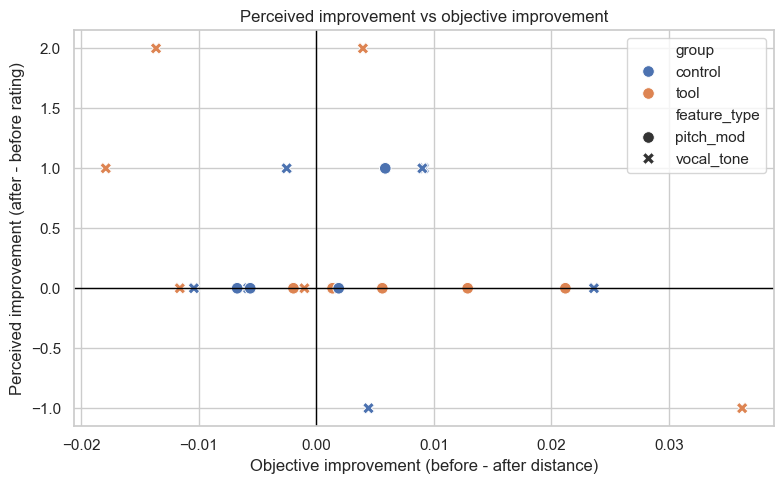

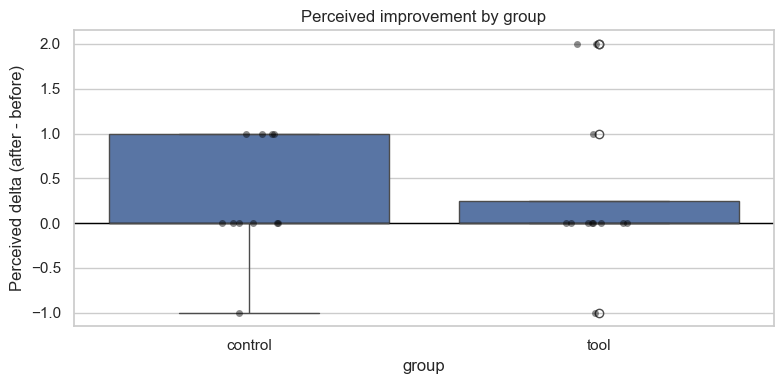

In [17]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, wilcoxon

# ---------- Helpers ----------
def parse_feature_group(section_key: str):
    sk = (section_key or "").lower()
    feature = "pitch_mod" if "pitch-modulation" in sk else ("vocal_tone" if "vocal-tone" in sk else None)
    group = "tool" if sk.endswith("-tool") else ("control" if sk.endswith("-control") else None)
    return feature, group

def extract_numeric(value):
    """Robustly get numeric value from structures like {}, {'': 4}, {'label': 3}, 4."""
    if value is None:
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, dict):
        # first numeric found
        for v in value.values():
            x = extract_numeric(v)
            if pd.notna(x):
                return x
    if isinstance(value, list):
        for v in value:
            x = extract_numeric(v)
            if pd.notna(x):
                return x
    return np.nan

def get_before_after(section):
    before_block = section.get("surveyBeforePracticeAnswers", {}) or {}
    after_block = section.get("surveyAfterPracticeAnswers", {}) or {}

    # Find the "How well do you think you controlled..." question in each block
    before_q = next((k for k in before_block.keys() if "How well do you think you controlled" in k), None)
    after_q  = next((k for k in after_block.keys()  if "How well do you think you controlled" in k), None)

    before_val = extract_numeric(before_block.get(before_q)) if before_q else np.nan
    after_val  = extract_numeric(after_block.get(after_q)) if after_q else np.nan
    return before_val, after_val

DOCS_PATH = Path("./data-analysis/data/musavoice_testing/musa_user_test_all_docs.json")
AUDIO_SUBJECTS_ROOT = Path("./data-analysis/downloaded_audios/musavoice_testing")

# whitelist from actual downloaded audio folders
valid_subject_ids = {
    p.name for p in AUDIO_SUBJECTS_ROOT.iterdir()
    if p.is_dir() and p.name.startswith("subject_")
}
print(f"Whitelisted subjects from audio folder: {len(valid_subject_ids)}")

# ---------- 1) Build perceived delta table ----------
docs = json.loads(DOCS_PATH.read_text())
perceived_rows = []

for doc in docs:
    sid = doc.get("subjectId")
    if sid not in valid_subject_ids:
        continue

    for sec in doc.get("sections", []):
        section_key = sec.get("sectionKey")
        feature_type, group = parse_feature_group(section_key)
        before_rating, after_rating = get_before_after(sec)

        perceived_rows.append({
            "subject": sid,
            "section": section_key,
            "feature_type": feature_type,
            "group": group,
            "before_rating": before_rating,
            "after_rating": after_rating,
            "perceived_delta": (after_rating - before_rating)
                if pd.notna(before_rating) and pd.notna(after_rating)
                else np.nan,
        })

perceived_df = pd.DataFrame(perceived_rows)
perceived_df_valid = perceived_df.dropna(subset=["perceived_delta"]).copy()

# ---------- 2) Build objective delta table from existing `df` ----------
quant = (
    df[df["subject"].isin(valid_subject_ids)]
    .pivot_table(
        index=["subject", "section"],
        columns="timing",
        values="distance_to_ref",
        aggfunc="mean"
    )
    .reset_index()
)

quant = quant.dropna(subset=["before", "after"]).copy()
quant["quant_delta"] = quant["before"] - quant["after"]

# add feature/group from section name
q_fg = quant["section"].apply(parse_feature_group)
quant["feature_type"] = q_fg.apply(lambda x: x[0])
quant["group"] = q_fg.apply(lambda x: x[1])

# ---------- 3) Merge perceived + objective ----------
merged = perceived_df_valid.merge(
    quant[["subject", "section", "quant_delta"]],
    on=["subject", "section"],
    how="inner"
)

print("Merged rows (usable for alignment):", len(merged))
display(merged.head())

# ---------- 4) Alignment: perception vs objective ----------
if len(merged) >= 3:
    rho, p = spearmanr(merged["perceived_delta"], merged["quant_delta"], nan_policy="omit")
    print(f"Overall Spearman(perceived_delta, quant_delta): rho={rho:.3f}, p={p:.4g}")

# by feature + group
rows = []
for (ft, grp), g in merged.groupby(["feature_type", "group"]):
    if len(g) >= 3:
        rho, p = spearmanr(g["perceived_delta"], g["quant_delta"], nan_policy="omit")
        rows.append({"feature_type": ft, "group": grp, "n": len(g), "rho": rho, "p_value": p})
align_stats = pd.DataFrame(rows).sort_values(["feature_type", "group"])
display(align_stats)

# simple sign agreement
merged["sign_match"] = np.sign(merged["perceived_delta"]) == np.sign(merged["quant_delta"])
print("Sign agreement rate:", merged["sign_match"].mean() if len(merged) else np.nan)

# ---------- 5) Did tool make people FEEL more improved? ----------
# compare perceived_delta tool vs control within same subject + feature_type
pvt = (
    merged.pivot_table(
        index=["subject", "feature_type"],
        columns="group",
        values=["perceived_delta", "quant_delta"],
        aggfunc="mean"
    )
)

# flatten columns
pvt.columns = [f"{a}_{b}" for a, b in pvt.columns]
pvt = pvt.reset_index()

# keep paired tool/control
mask = pvt[["perceived_delta_tool", "perceived_delta_control"]].notna().all(axis=1)
pair = pvt.loc[mask].copy()

if len(pair) >= 2:
    pair["perceived_tool_minus_control"] = pair["perceived_delta_tool"] - pair["perceived_delta_control"]
    # optional objective counterpart
    if {"quant_delta_tool", "quant_delta_control"}.issubset(pair.columns):
        pair["quant_tool_minus_control"] = pair["quant_delta_tool"] - pair["quant_delta_control"]

    w = wilcoxon(pair["perceived_delta_tool"], pair["perceived_delta_control"], alternative="two-sided")
    print(f"Wilcoxon paired (perceived tool vs control): n={len(pair)}, p={w.pvalue:.4g}")
    print("Mean perceived(tool-control):", pair["perceived_tool_minus_control"].mean())

display(pair.head())

# ---------- 6) Visuals ----------
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged, x="quant_delta", y="perceived_delta", hue="group", style="feature_type", s=70)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title("Perceived improvement vs objective improvement")
plt.xlabel("Objective improvement (before - after distance)")
plt.ylabel("Perceived improvement (after - before rating)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=merged, x="group", y="perceived_delta")
sns.stripplot(data=merged, x="group", y="perceived_delta", color="black", alpha=0.45)
plt.axhline(0, color="black", linewidth=1)
plt.title("Perceived improvement by group")
plt.ylabel("Perceived delta (after - before)")
plt.tight_layout()
plt.show()

Positive tokens: 57
Negative tokens: 16
Positive %: 78.1%
Negative %: 21.9%


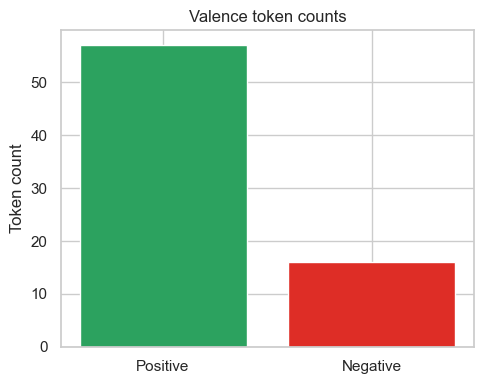

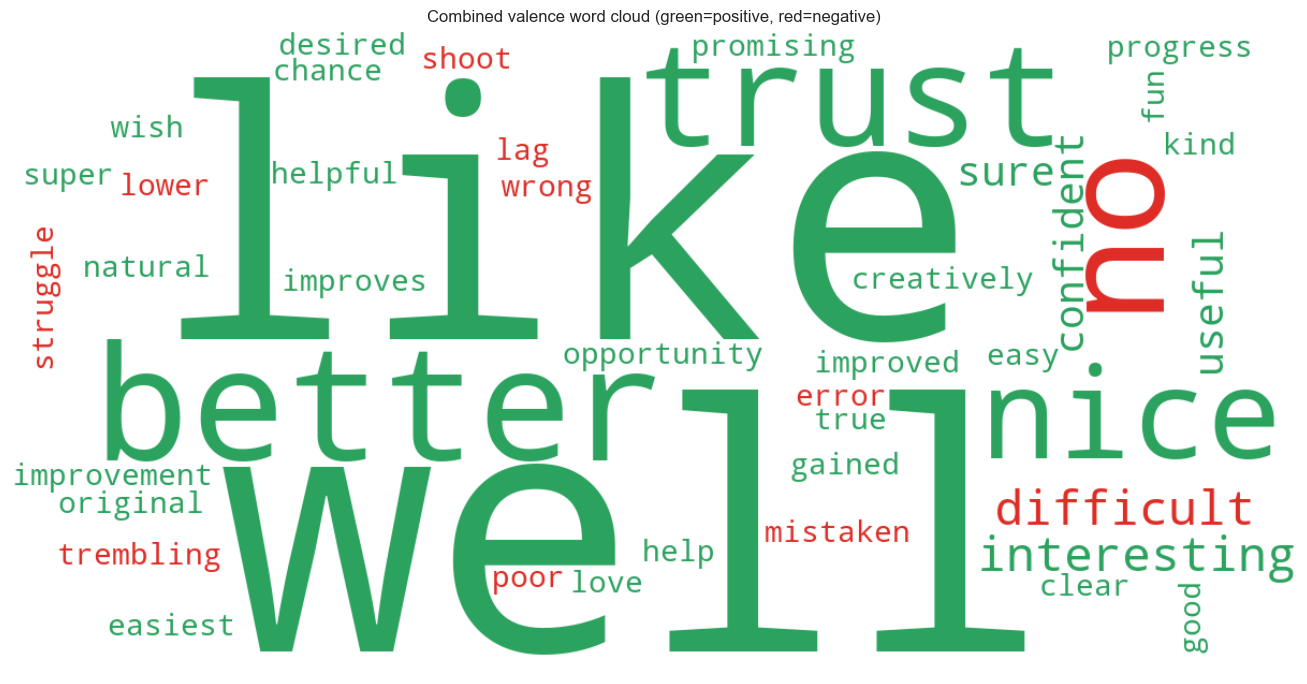

In [ ]:
import json
import re
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon", quiet=True)

DOCS_PATH = Path("./data-analysis/data/musavoice_testing/musa_user_test_all_docs.json")
docs = json.loads(DOCS_PATH.read_text())

def collect_text_values(x):
    out = []
    if isinstance(x, dict):
        for v in x.values():
            out.extend(collect_text_values(v))
    elif isinstance(x, list):
        for v in x:
            out.extend(collect_text_values(v))
    elif isinstance(x, str):
        s = x.strip()
        if s and s.lower() not in {"-", "n/a", "na", "none"} and "@" not in s:
            out.append(s)
    return out

texts = []
for d in docs:
    ex = d.get("exitSurveyAnswers")
    if isinstance(ex, dict) and len(ex) > 0:
        texts.extend(collect_text_values(ex))

corpus = " ".join(texts).lower()
tokens = re.findall(r"[a-z']+", corpus)

# VADER valence lexicon
sia = SentimentIntensityAnalyzer()
lex = sia.lexicon  # dict: word -> valence score

# keep only valence words (abs(score) >= 1.0)
valence_tokens = [w for w in tokens if w in lex and abs(lex[w]) >= 1.0]

pos_counts = Counter([w for w in valence_tokens if lex[w] > 0])
neg_counts = Counter([w for w in valence_tokens if lex[w] < 0])

# Totals
n_pos = sum(pos_counts.values())
n_neg = sum(neg_counts.values())
n_total = n_pos + n_neg

print(f"Positive tokens: {n_pos}")
print(f"Negative tokens: {n_neg}")
if n_total > 0:
    print(f"Positive %: {100*n_pos/n_total:.1f}%")
    print(f"Negative %: {100*n_neg/n_total:.1f}%")

# Simple bar chart
plt.figure(figsize=(5, 4))
plt.bar(["Positive", "Negative"], [n_pos, n_neg], color=["#2ca25f", "#de2d26"])
plt.title("Valence token counts")
plt.ylabel("Token count")
plt.tight_layout()
plt.show()

# Combined valence cloud (green=positive, red=negative)
combined_counts = Counter()
combined_counts.update(pos_counts)
combined_counts.update(neg_counts)

def valence_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    score = lex.get(word, 0)
    return "#2ca25f" if score > 0 else "#de2d26"

if combined_counts:
    wc_combined = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate_from_frequencies(combined_counts)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc_combined.recolor(color_func=valence_color_func), interpolation="bilinear")
    plt.axis("off")
    plt.title("Combined valence word cloud (green=positive, red=negative)")
    plt.tight_layout()
    plt.show()